# Optimization for AI Project - Deiana

For this project, we will explore and try to replicate the results of the following paper. In this paper, the authors aim to use a modified version of GA to synthesize a digital FIR filter given a desired frequency response.

A digital FIR filter is characterized by the following transfer function: $H(s)=\sum^{N}_{n=0}a_nz^{-n}$, where N is the order of the filter, and $a_n$ is
defined as the filter coefficients. As we can clearly see, an individual in this case is simply a finite vector of real values. Since the original paper is concerned with hardware filter design, two binary encodings are proposed: ternary and mixed. The filters are encoded in these binary forms because it makes it easy to check if the individuals follow the canonical signed-digit (CSD) constraints. These constraints are important for creating hardware versions of the filter from the binary representation using as little circuitry as possible.

## Proof of concept

Before we implement the techniques proposed in the paper, it could be interesting to create a simple proof of concept at a higher level. We will implement the classic GA, and encode the individuals as simple vectors of real numbers, disregarding for a moment the physical limitations the paper is concerned with.

The GA will be implemented as follows:
- Chromosome: $x=(x_1,…,x_n)$, where $x_i \in [-1, 1] \forall i \in {0, ..., n}$
- Init: Uniform sampling per gene
- Mutation: Gaussian
- Crossover: One point crossover on the chromosome
- Selection: Roulette Wheel
- Fitness: $f(x) = \frac{1}{error_{minimax}}$, $error_{minimax} = max||H_{target}(j\omega)|-|H_{ind}(j\omega)||$

We will use the signal library from scipy for calculating the frequency response of each individual, together with numpy. For everything else, standard python is enough to implement the GA.

### Implementation

In [34]:
import random, bisect
import numpy as np
from scipy.signal import freqz

In [35]:
def get_individual(order):
    individual = []
    for _ in range(order):
        individual.append(random.uniform(-1, 1))
    return individual

In [36]:
def init_pop(order, n_pop):
    return [get_individual(order) for _ in range(n_pop)]

In [37]:
def mut(individual):
    mutated = []
    for coeff in individual:
        if random.random() < 0.5:
            mutated.append(coeff + random.gauss())
        else:
            mutated.append(coeff)
    return mutated

In [38]:
def cross(parent1, parent2):
    p = random.randint(1, len(parent1)-1)
    return parent1[:p] + parent2[p:]

In [39]:
def fit(individual, target):
    wi, Hi = np.array(freqz(individual))
    wt, Ht = np.array(freqz(target))
    error = max(np.abs(np.abs(Ht) - np.abs(Hi)))
    return 1/error

In [40]:
def selection(pop, n_pop, fitness, target):
    # Compute fitness values once
    fvals = [fitness(ind, target) for ind in pop]
    tot = sum(fvals)
    # Build cumulative distribution
    cum = []
    s = 0.0
    for fv in fvals:
        s += fv
        cum.append(s)
    newpop = []
    for _ in range(n_pop):
        r = random.random() * tot  # r ∈ [0, tot)
        idx = bisect.bisect_left(cum, r)
        newpop.append(pop[idx])
    return newpop

In [41]:
def GA(n_pop, generations, order, target):
    pop = []
    best = []
    # Population initialization
    pop = init_pop(order, n_pop)
    for _ in range(generations):
        best.append(max(pop, key=lambda x: fit(x, target)))
        for _ in range(n_pop):
            parent1 = pop[random.randint(0, len(pop)-1)]
            parent2 = pop[random.randint(0, len(pop)-1)]
            child1 = mut(cross(parent1, parent2))
            child2 = mut(cross(parent2, parent1))
            pop.append(child1)
            pop.append(child2)
        pop = selection(pop, n_pop, fit, target)
    return best

In [42]:
n_pop = 50
generations = 300
order = 5
target = [-0.2, 0.8, 0.613, -0.93, -0.01]

best = GA(n_pop, generations, order, target)


### Results Analysis

In [43]:
import matplotlib.pyplot as plt

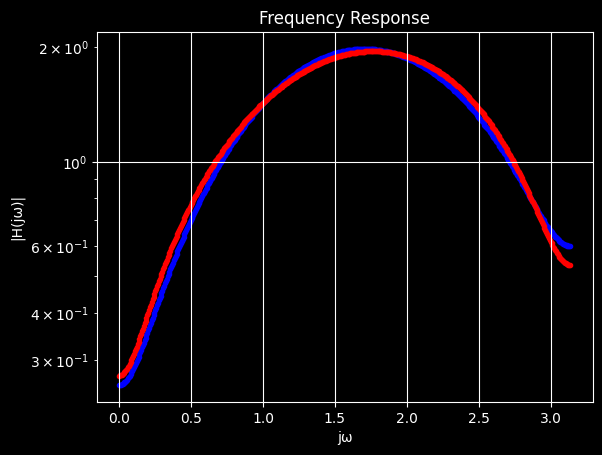

In [44]:
wb, Hb = freqz(best[-1])
wt, Ht = freqz(target)
Hb = abs(Hb)
Ht = abs(Ht)
plt.scatter(wb, Hb, c='blue', marker='.')
plt.scatter(wt, Ht, c='red', marker='.')
plt.xlabel("jω")
plt.ylabel("|H(jω)|")
plt.yscale('log')
plt.title("Frequency Response")
plt.grid(True)
plt.show()


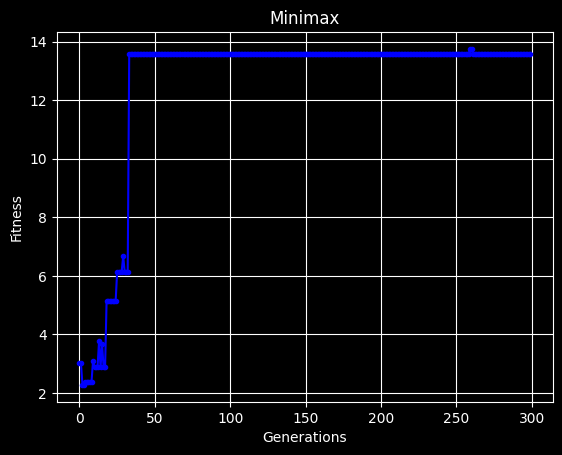

In [45]:
plt.plot([fit(b, target) for b in best], c='blue', marker='.')
plt.xlabel("Generations")
plt.ylabel("Fitness")
plt.title("Minimax")
plt.grid(True)
plt.show()

As we can see from this demonstration, this simple GA algorithm is already good enough to provide a decent fit at around 250 generations.

### Testing "classic" FIR filters

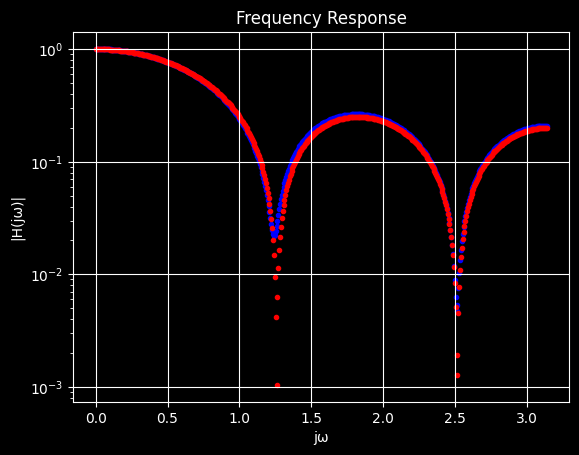

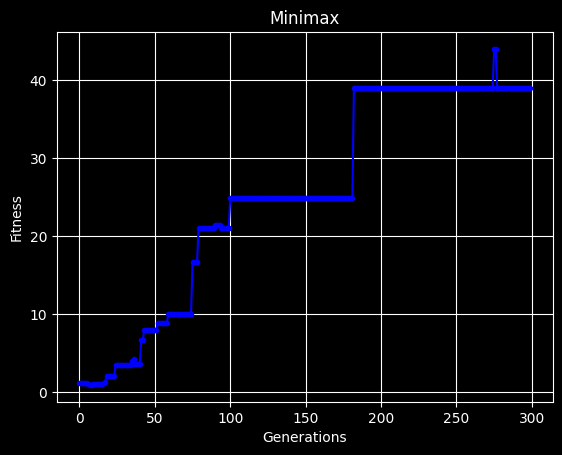

In [46]:
# 1. Moving-Average (Boxcar) FIR
target = [
    0.2, 0.2, 0.2, 0.2, 0.2
]
order = len(target)
best = GA(n_pop, generations, order, target)
wb, Hb = freqz(best[-1])
wt, Ht = freqz(target)
Hb = abs(Hb)
Ht = abs(Ht)
plt.scatter(wb, Hb, c='blue', marker='.')
plt.scatter(wt, Ht, c='red', marker='.')
plt.xlabel("jω")
plt.ylabel("|H(jω)|")
plt.yscale('log')
plt.title("Frequency Response")
plt.grid(True)
plt.show()
plt.plot([fit(b, target) for b in best], c='blue', marker='.')
plt.xlabel("Generations")
plt.ylabel("Fitness")
plt.title("Minimax")
plt.grid(True)
plt.show()

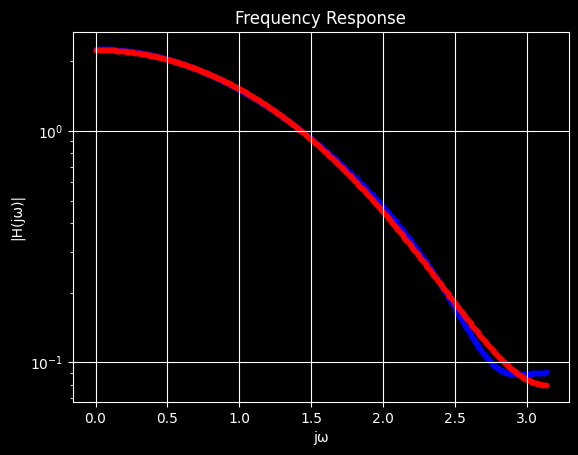

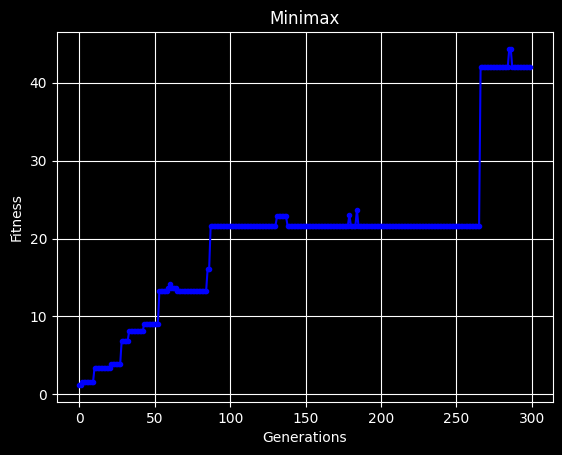

In [47]:
# 2. Window Functions (5-tap examples)
target = [
    0.08,
    0.54,
    1.00,
    0.54,
    0.08
]
order = len(target)
best = GA(n_pop, generations, order, target)
wb, Hb = freqz(best[-1])
wt, Ht = freqz(target)
Hb = abs(Hb)
Ht = abs(Ht)
plt.scatter(wb, Hb, c='blue', marker='.')
plt.scatter(wt, Ht, c='red', marker='.')
plt.xlabel("jω")
plt.ylabel("|H(jω)|")
plt.yscale('log')
plt.title("Frequency Response")
plt.grid(True)
plt.show()
plt.plot([fit(b, target) for b in best], c='blue', marker='.')
plt.xlabel("Generations")
plt.ylabel("Fitness")
plt.title("Minimax")
plt.grid(True)
plt.show()

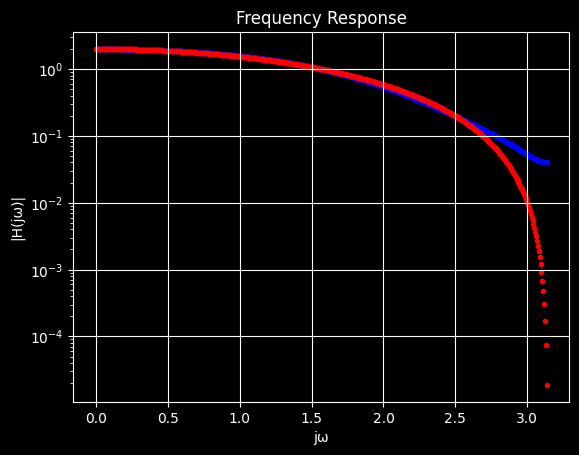

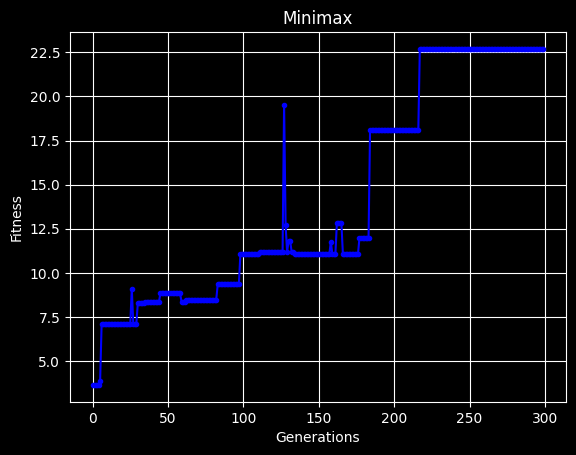

In [48]:
target = [
    0.0,
    0.5,
    1.0,
    0.5,
    0.0
]
order = len(target)
best = GA(n_pop, generations, order, target)
wb, Hb = freqz(best[-1])
wt, Ht = freqz(target)
Hb = abs(Hb)
Ht = abs(Ht)
plt.scatter(wb, Hb, c='blue', marker='.')
plt.scatter(wt, Ht, c='red', marker='.')
plt.xlabel("jω")
plt.ylabel("|H(jω)|")
plt.yscale('log')
plt.title("Frequency Response")
plt.grid(True)
plt.show()
plt.plot([fit(b, target) for b in best], c='blue', marker='.')
plt.xlabel("Generations")
plt.ylabel("Fitness")
plt.title("Minimax")
plt.grid(True)
plt.show()

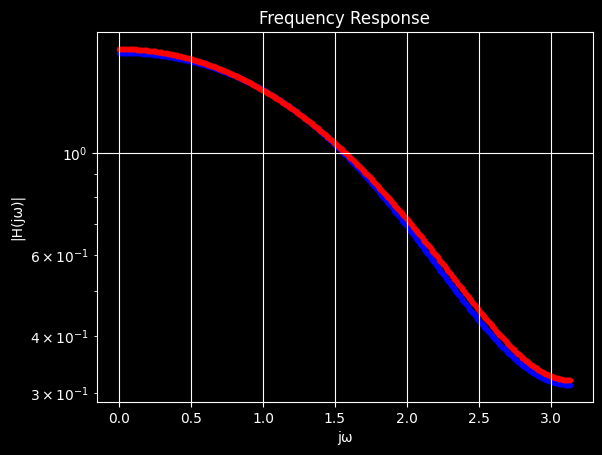

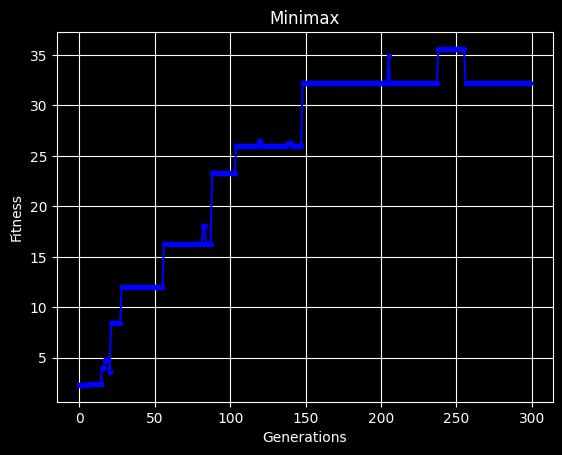

In [49]:
target = [
    -0.00,
    0.34,
    1.00,
    0.34,
    -0.00
]
order = len(target)
best = GA(n_pop, generations, order, target)
wb, Hb = freqz(best[-1])
wt, Ht = freqz(target)
Hb = abs(Hb)
Ht = abs(Ht)
plt.scatter(wb, Hb, c='blue', marker='.')
plt.scatter(wt, Ht, c='red', marker='.')
plt.xlabel("jω")
plt.ylabel("|H(jω)|")
plt.yscale('log')
plt.title("Frequency Response")
plt.grid(True)
plt.show()
plt.plot([fit(b, target) for b in best], c='blue', marker='.')
plt.xlabel("Generations")
plt.ylabel("Fitness")
plt.title("Minimax")
plt.grid(True)
plt.show()

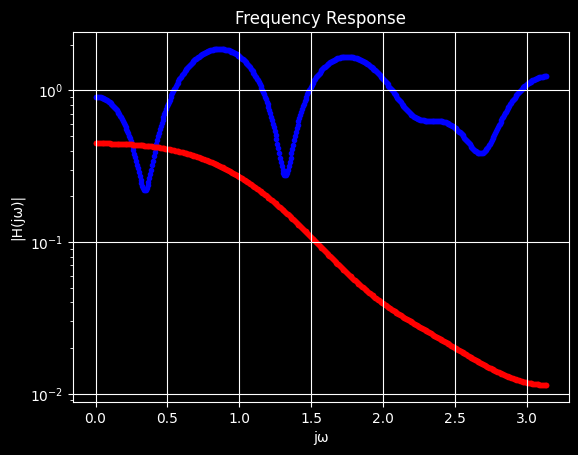

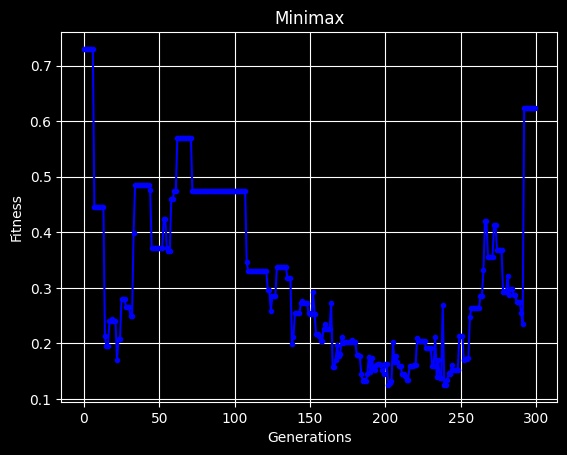

In [50]:
# 3. Parks–McClellan (Remez) Low-Pass FIR (11 taps)
target = [
    -0.0017, -0.0056,  0.0000,  0.0343,  0.1105,
    0.1716,
    0.1105,  0.0343,  0.0000, -0.0056, -0.0017
]
order = len(target)
best = GA(n_pop, generations, order, target)
wb, Hb = freqz(best[-1])
wt, Ht = freqz(target)
Hb = abs(Hb)
Ht = abs(Ht)
plt.scatter(wb, Hb, c='blue', marker='.')
plt.scatter(wt, Ht, c='red', marker='.')
plt.xlabel("jω")
plt.ylabel("|H(jω)|")
plt.yscale('log')
plt.title("Frequency Response")
plt.grid(True)
plt.show()
plt.plot([fit(b, target) for b in best], c='blue', marker='.')
plt.xlabel("Generations")
plt.ylabel("Fitness")
plt.title("Minimax")
plt.grid(True)
plt.show()

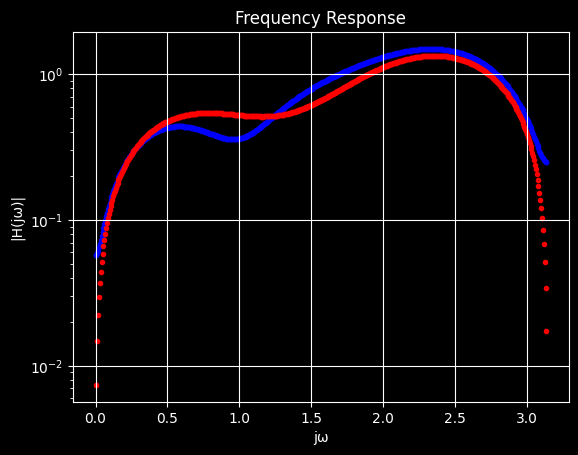

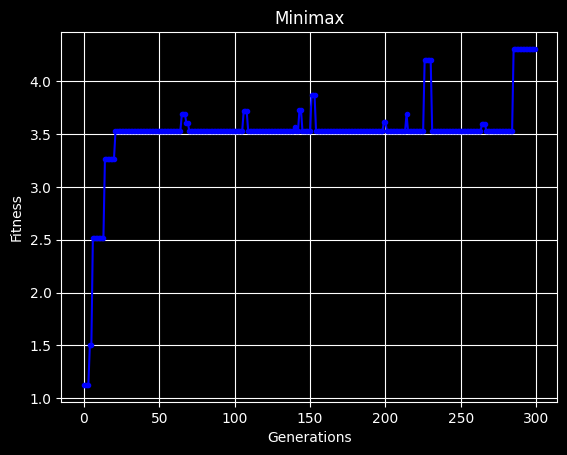

In [51]:
# 4. Type-III Differentiator FIR (7 taps)
target = [
    -0.1667,
    0.2,
    -0.5,
    0.0,
    0.5,
    -0.2,
    0.1667
]
order = len(target)
best = GA(n_pop, generations, order, target)
wb, Hb = freqz(best[-1])
wt, Ht = freqz(target)
Hb = abs(Hb)
Ht = abs(Ht)
plt.scatter(wb, Hb, c='blue', marker='.')
plt.scatter(wt, Ht, c='red', marker='.')
plt.xlabel("jω")
plt.ylabel("|H(jω)|")
plt.yscale('log')
plt.title("Frequency Response")
plt.grid(True)
plt.show()
plt.plot([fit(b, target) for b in best], c='blue', marker='.')
plt.xlabel("Generations")
plt.ylabel("Fitness")
plt.title("Minimax")
plt.grid(True)
plt.show()

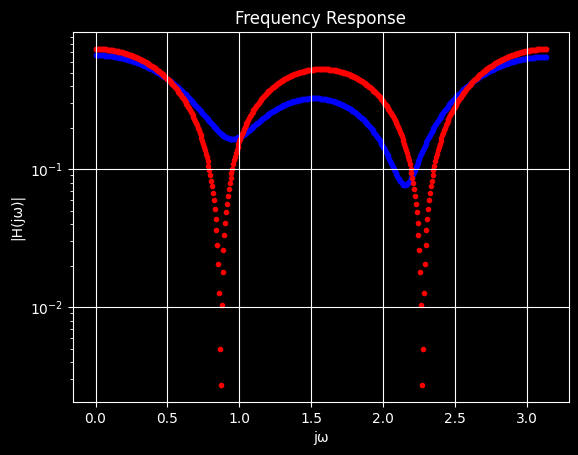

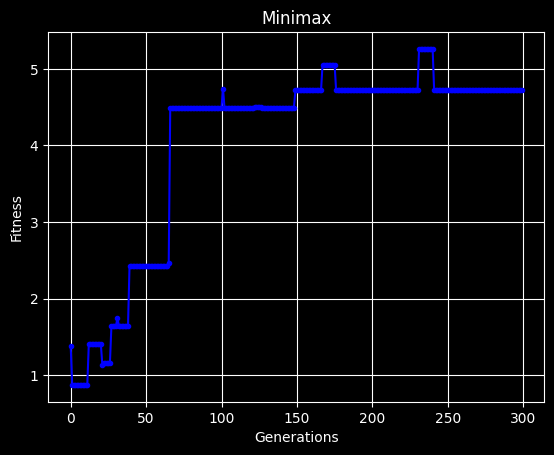

In [52]:
# 5. Hilbert Transformer FIR (7 taps)
target = [
    0.0,
    -0.3183,
    0.0,
    -0.1061,
    0.0,
    -0.3183,
    0.0
]
order = len(target)
best = GA(n_pop, generations, order, target)
wb, Hb = freqz(best[-1])
wt, Ht = freqz(target)
Hb = abs(Hb)
Ht = abs(Ht)
plt.scatter(wb, Hb, c='blue', marker='.')
plt.scatter(wt, Ht, c='red', marker='.')
plt.xlabel("jω")
plt.ylabel("|H(jω)|")
plt.yscale('log')
plt.title("Frequency Response")
plt.grid(True)
plt.show()
plt.plot([fit(b, target) for b in best], c='blue', marker='.')
plt.xlabel("Generations")
plt.ylabel("Fitness")
plt.title("Minimax")
plt.grid(True)
plt.show()